In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import pandas as pd

## Slurm job 869

PC dirs found: ['pc_002', 'pc_003', 'pc_004', 'pc_005', 'pc_006', 'pc_007', 'pc_008', 'pc_016', 'pc_032', 'pc_064', 'pc_128', 'pc_256']


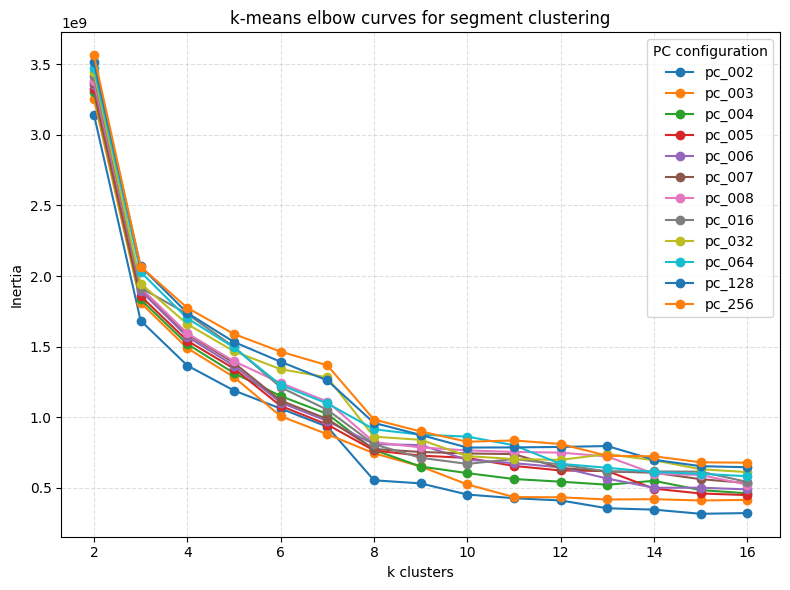

In [2]:
BASE_DIR = Path("D:/seg_clust_869")

# Find all pc_* directories
pc_dirs = sorted(
    d for d in BASE_DIR.iterdir()
    if d.is_dir() and d.name.startswith("pc_")
)

print("PC dirs found:", [d.name for d in pc_dirs])

plt.figure(figsize=(8, 6))

for i, pc_dir in enumerate(pc_dirs):
    if i >= 16:
        print("Skipping extra pc_dir:", pc_dir.name)
        continue
    summary_path = pc_dir / "kmeans_summary.npz"
    data = np.load(summary_path)

    k_values = data["k_values"]
    inertias = data["inertias"]

    plt.plot(
        k_values,
        inertias,
        marker="o",
        label=pc_dir.name,
    )

plt.xlabel("k clusters")
plt.ylabel("Inertia")
plt.title("k-means elbow curves for segment clustering")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(title="PC configuration")
plt.tight_layout()
plt.show()


In [3]:
pc_dir = BASE_DIR / "pc_002"

K_TARGET = 8
k_dir = pc_dir / f"k_{K_TARGET:02d}"

# load arrays
X = np.load(k_dir / "segment_meta.npy")      # shape (N, D) – assumed features in PCA space
labels = np.load(k_dir / "segment_labels.npy")  # shape (N,)
centers = np.load(k_dir / "kmeans_centers.npy") # shape (K, D)

In [4]:
print("X shape:", X.shape)
print("labels shape:", labels.shape)
print("centers shape:", centers.shape)

X shape: (108000,)
labels shape: (108000,)
centers shape: (8, 2)


In [5]:
import numpy.lib.format as fmt
path = BASE_DIR / "sampled_paths.npy"

with path.open("rb") as f:
    version = fmt.read_magic(f)
    print("npy version:", version)
    shape, fortran_order, dtype = fmt.read_array_header_1_0(f)
    print("shape:", shape)
    print("fortran_order:", fortran_order)
    print("dtype:", dtype)

npy version: (1, 0)
shape: (2000,)
fortran_order: False
dtype: object


In [6]:
K_DIR = Path(r"D:\seg_clust_869\pc_002\k_08")

centers = np.load(K_DIR / "kmeans_centers.npy")       # shape (K, D)
labels  = np.load(K_DIR / "segment_labels.npy")       # shape (N,)
dist2   = np.load(K_DIR / "segment_dist2.npy")        # shape (N,)
meta    = np.load(K_DIR / "segment_meta.npy")         # structured array (N,)

nearest_df = pd.read_csv(K_DIR / "nearest_segments.csv")  # 1 row per cluster, usually

print("centers:", centers.shape)
print("labels:", labels.shape)
print("dist2:", dist2.shape)
print("meta:", meta.shape, "dtype:", meta.dtype)
print(nearest_df.head())
print("Example meta row:", meta[0])

centers: (8, 2)
labels: (108000,)
dist2: (108000,)
meta: (108000,) dtype: [('file_path', '<U256'), ('segment_idx', '<i4'), ('start_frame', '<i4'), ('end_frame', '<i4')]
   cluster  rank  dist2                                    feature_segment
0        0     1   84.0  /home/trh104/second_extraction/Sep_6229/6229.2...
1        0     2  192.0  /home/trh104/second_extraction/Sep_6229/6229.2...
2        0     3  468.0  /home/trh104/second_extraction/Sep_6229/6229.2...
3        0     4  472.0  /home/trh104/second_extraction/Aug_6229/6229.2...
4        0     5  550.0  /home/trh104/second_extraction/Aug_6229/6229.2...
Example meta row: ('/home/trh104/second_extraction/Tracy_6230/6230.220928030000.npz', 0, 0, 613)


centers shape: (8, 2)


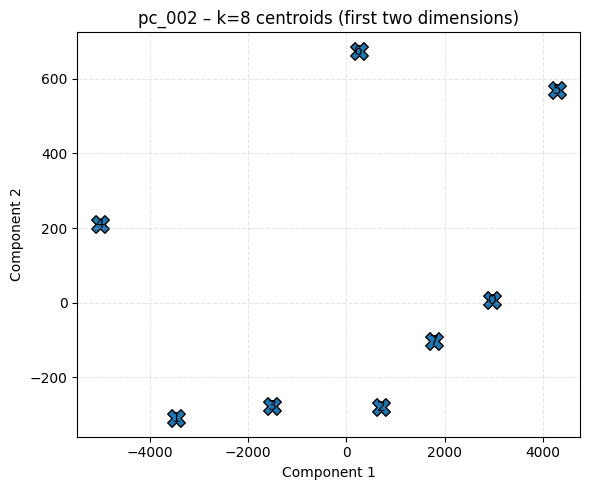

In [7]:
k_dir = Path(r"D:\seg_clust_869\pc_002\k_08")
centers = np.load(k_dir / "kmeans_centers.npy")   # shape (K, D)
print("centers shape:", centers.shape)
centers_2d = centers[:, :2]

plt.figure(figsize=(6, 5))
plt.scatter(
    centers_2d[:, 0],
    centers_2d[:, 1],
    marker="X",
    s=160,
    edgecolor="black",
    linewidth=1.0,
)

for i, (x, y) in enumerate(centers_2d):
    plt.text(x, y, f"{i}", fontsize=10, ha="center", va="center")

plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.title("pc_002 – k=8 centroids (first two dimensions)")
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()


## Slurm job 1733

In [19]:
BASE_DIR = Path("D:/seg_clust_1733")
graph_path = r"C:\Users\Lindholm\Documents\BSc\bsc_project\research\graphs\graphs_wk12"

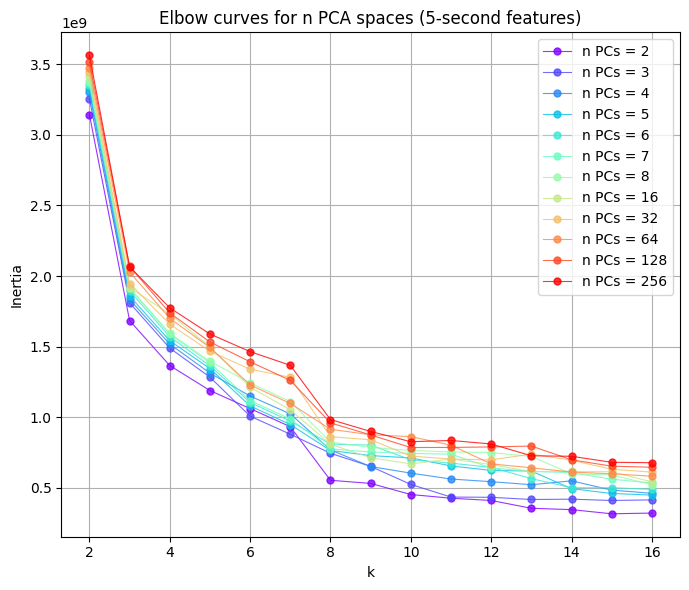

In [30]:
pcs = sorted([p for p in BASE_DIR.iterdir() if p.name.startswith("pc_")])

plt.figure(figsize=(7,6))
cmap =plt.get_cmap("rainbow")
colors = cmap(np.linspace(0,1,len(pcs)))

for pc_dir, color in zip(pcs, colors):
    summ = np.load(pc_dir / "kmeans_summary.npz")
    k = summ["k_values"]
    inertia = summ["inertias"]
    n_pc = int(summ["n_pc"])
    plt.plot(k, inertia, marker="o", markersize=5, label=f"n PCs = {n_pc}", alpha=0.8, lw=0.8, color=color)

plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow curves for n PCA spaces (5-second features)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(Path(graph_path) / "elbow_curves_segments_wk12.png", dpi=300)
plt.show()
